# Full-slab sparse crystal-edit ptychography

This notebook asks whether diffraction can recover sparse edits and non-affine host motion in the complete **1000 Å by 50 Å** silicon side view. The inverse model receives the diamond host, silicon species, approximate lattice scale, fixed probe and scan geometry, and a fixed latent (y) layer for added atoms. It does not receive the displacement field, vacancy, added-atom position, or defect count.

The reconstruction separates three operations. Ten diffraction-only coordinate updates are followed by one weak Keating proximal update, while five temporary signed-pixel updates are used only to propose missing structure. The pixel field is discarded before every physical fit and is never part of the reported specimen.


In [1]:
%matplotlib widget
from pathlib import Path
import os, sys
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", ".8")
repo_root = Path.cwd() if (Path.cwd() / "wide_angle_propagation").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

import abtem
from ase import Atoms
from ase.build import bulk
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from scipy.spatial import cKDTree

from wide_angle_propagation.notebook_utils import make_crystal_reconstruction_viewer_1d
from wide_angle_propagation.propagation_methods import angular_spectrum_propagation_kernel_1d, energy2wavelength
from wide_angle_propagation.ptychography_1d import normalized_amplitude_loss_1d, simulate_glancing_scan_1d
from wide_angle_propagation.ptychography_crystal_1d import (
    CrystalState1D, make_crystal_model_1d, make_si_atom_template_1d,
    reconstruct_crystal_1d, render_crystal_1d,
)
abtem.config.set({"device": "cpu", "precision": "float64"})


## 1. Reproduce the 1000 Å side-view specimen

The forward specimen and aperture-limited probe use the same construction as the side-view viewer: 30 keV, 2° incidence, a 15 mrad convergence semiangle, and 21 surface landings from 400–600 Å. The finite abTEM potential supplies the synthetic reference, whereas the inverse model is assembled independently from latent diamond sites and one compact Lobato Si template.


In [2]:
energy_eV, glancing_angle_deg, convergence_mrad = 30_000.0, 2.0, 15.0
beam_tilt_rad, propagation_length_A, slab_depth_A = -np.deg2rad(glancing_angle_deg), 1000.0, 50.0
vacuum_above_A, vacuum_below_A, si_lattice_A = 40.0, 20.0, 5.431
surface_global_A = vacuum_below_A + slab_depth_A
transverse_extent_A = vacuum_below_A + slab_depth_A + vacuum_above_A
si_unit, surface_clearance_A = bulk("Si", "diamond", a=si_lattice_A, cubic=True), si_lattice_A / 8.0
repeated = si_unit.repeat((int(np.ceil(slab_depth_A / si_lattice_A)) + 1, 1,
                           int(np.ceil(propagation_length_A / si_lattice_A)) + 1))
positions_A = repeated.positions
inside = ((positions_A[:, 0] <= slab_depth_A - surface_clearance_A + 1e-9)
          & (positions_A[:, 2] < propagation_length_A - 1e-9))
positions_A = positions_A[inside].copy()
positions_A[:, 0] = surface_global_A - surface_clearance_A - positions_A[:, 0]
si_slab = Atoms(["Si"] * len(positions_A), positions=positions_A,
                cell=(transverse_extent_A, si_lattice_A, propagation_length_A), pbc=(False, True, False))
builder = abtem.Potential(si_slab, sampling=(0.115, 0.20), slice_thickness=si_lattice_A,
                          projection="finite", parametrization="lobato", plane="xz",
                          periodic=False, device="cpu")
finite_projected = np.asarray(builder.build(lazy=False).array)[0]
du, ds = map(float, builder.sampling)
n_u, n_s = finite_projected.shape
s_A, u_A = np.arange(n_s) * ds, np.arange(n_u) * du - surface_global_A
pristine_abtem_potential = finite_projected.T / si_lattice_A
reference_positions_3d = np.stack(
    [positions_A[:, 2], positions_A[:, 1], positions_A[:, 0] - surface_global_A], axis=1)
print({"shape": (n_s, n_u), "sampling Å": (ds, du), "host sites": len(reference_positions_3d)})


{'shape': (5000, 957), 'sampling Å': (0.2, 0.11494252873563218), 'host sites': 13635}


In [3]:
wavelength_A = float(energy2wavelength(energy_eV))
scan_coordinates_A = np.linspace(400.0, 600.0, 21)
beam_centres_A = -scan_coordinates_A * np.tan(beam_tilt_rad)
frequencies = np.fft.fftfreq(n_u, d=du)
qx, qy = np.meshgrid(frequencies, frequencies, indexing="xy")
pupil = (qx**2 + qy**2) <= (np.sin(convergence_mrad * 1e-3) / wavelength_A)**2
probe_2d = np.fft.fftshift(np.fft.ifft2(pupil))
probe_line = probe_2d[n_u // 2] / np.max(np.abs(probe_2d[n_u // 2]))
probe_spectrum = np.fft.fft(probe_line)
carrier = np.exp(2j * np.pi * np.sin(beam_tilt_rad) * u_A / wavelength_A)
input_probes = jnp.asarray([
    np.fft.ifft(probe_spectrum * np.exp(-2j * np.pi * frequencies * (center - u_A[n_u // 2]))) * carrier
    for center in beam_centres_A
], dtype=jnp.complex128)
kernel = angular_spectrum_propagation_kernel_1d(n_u, du, ds, energy_eV)
window_starts = jnp.zeros(21, dtype=jnp.int32)
detector_angles_mrad = 1e3 * np.arcsin(np.clip(wavelength_A * np.fft.fftshift(frequencies), -1.0, 1.0))
audit_indices, selection_indices = np.asarray([0, 7, 14]), np.asarray([3, 10, 17])
training_indices = np.setdiff1d(np.arange(21), np.r_[audit_indices, selection_indices])
si_template = make_si_atom_template_1d(ds, du, projection_width_A=si_lattice_A)
model = make_crystal_model_1d(
    s_A, u_A, si_template, reference_positions_3d, scan_coordinates_A, training_indices,
    beam_tilt_rad=beam_tilt_rad,
    airy_first_zero_A=0.61 * wavelength_A / (convergence_mrad * 1e-3),
    slab_bounds_A=(-slab_depth_A, 0.0), axial_period_A=si_lattice_A / 2.0, latent_period_A=si_lattice_A)
display({"training / selection / audit": tuple(map(len, (training_indices, selection_indices, audit_indices))),
         "mobile / core hosts": (int(np.count_nonzero(model.host_mobility)),
                                  int(np.count_nonzero(model.full_mobility_mask))),
         "insertion anchors": len(model.insertion_anchors_3d)})


{'training / selection / audit': (15, 3, 3),
 'mobile / core hosts': (3440, 2600),
 'insertion anchors': 19648}

## 2. Construct references that were not relaxed with Keating

Both gates use a smooth wedge-supported displacement field and the same deliberately imperfect global registration. The defect reference additionally removes the surface host nearest the 500 Å landing, adds one off-lattice Si atom, and relaxes nearby hosts with an imposed local field. Keating therefore regularizes the inverse coordinates but does not generate the answers used to test it.


In [4]:
def state_positions(state):
    reference, registration = np.asarray(model.reference_positions_3d), np.asarray(state.registration)
    projected, center = reference[:, [0, 2]], reference[:, [0, 2]].mean(axis=0)
    relative = projected - center
    relative[:, 0] *= 1.0 + registration[3]
    angle = registration[2]
    rotation = np.asarray([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    result = reference.copy()
    result[:, [0, 2]] = relative @ rotation.T + center + registration[:2] + np.asarray(state.host_displacements)
    return result

def abtem_potential_from_state(state):
    host = state_positions(state)[~np.asarray(state.removed_host_mask)]
    extras = np.asarray(state.extra_positions_3d)[np.asarray(state.extra_active_mask)]
    latent = np.concatenate([host, extras])
    xyz = np.stack([latent[:, 2] + surface_global_A, latent[:, 1], latent[:, 0]], axis=1)
    inside = ((xyz[:, 0] >= 0.0) & (xyz[:, 0] < transverse_extent_A)
              & (xyz[:, 2] >= 0.0) & (xyz[:, 2] < propagation_length_A))
    atoms = Atoms(["Si"] * int(inside.sum()), positions=xyz[inside],
                  cell=(transverse_extent_A, si_lattice_A, propagation_length_A), pbc=(False, True, False))
    potential = abtem.Potential(atoms, gpts=(n_u, n_s), slice_thickness=si_lattice_A,
                               projection="finite", parametrization="lobato", plane="xz",
                               periodic=False, device="cpu")
    return np.asarray(potential.build(lazy=False).array)[0].T / si_lattice_A

n_host = len(reference_positions_3d)
registration_truth = jnp.asarray([0.20, 0.10, np.deg2rad(0.15), 0.002])
t = np.clip((reference_positions_3d[:, 0] - 400.0) / 600.0, 0.0, 1.0)
envelope = np.sin(np.pi * t) * np.asarray(model.host_mobility)
host_displacements = np.stack([0.025 * np.sin(2 * np.pi * t) * envelope,
                               0.020 * np.cos(2 * np.pi * t) * envelope], axis=1)
empty_extras = np.zeros((model.max_extra_atoms, 3))
empty_extras[:, 1] = si_lattice_A / 4.0
strained_state = CrystalState1D(registration_truth, jnp.asarray(host_displacements),
                                jnp.zeros(n_host, bool), jnp.asarray(empty_extras),
                                jnp.zeros(model.max_extra_atoms, bool))
surface = np.isclose(reference_positions_3d[:, 2], reference_positions_3d[:, 2].max())
eligible_indices = np.flatnonzero(surface & np.asarray(model.full_mobility_mask))
vacancy_index = int(eligible_indices[np.argmin(abs(reference_positions_3d[eligible_indices, 0] - 500.0))])
vacancy_position = reference_positions_3d[vacancy_index]
direction = reference_positions_3d[:, [0, 2]] - vacancy_position[[0, 2]]
distance = np.linalg.norm(direction, axis=1)
direction /= np.maximum(distance[:, None], 1e-12)
defect_displacements = host_displacements + 0.08 * np.exp(-(distance / 4.0)**2)[:, None] * direction
removed, extra_active, defect_extras = np.zeros(n_host, bool), np.zeros(model.max_extra_atoms, bool), empty_extras.copy()
removed[vacancy_index], extra_active[0] = True, True
defect_extras[0] = [vacancy_position[0] + 0.65, si_lattice_A / 4.0, vacancy_position[2] + 1.9]
defect_state = CrystalState1D(registration_truth, jnp.asarray(defect_displacements), jnp.asarray(removed),
                              jnp.asarray(defect_extras), jnp.asarray(extra_active))


## 3. Simulate diffraction and declare the mismatch floor

The forward references use independently rasterized abTEM potentials, whereas reconstruction uses the differentiable atomic renderer. We therefore measure the pristine renderer floor before introducing either unknown specimen. The acceptance threshold is fixed as the larger of (10^{-3}) and 1.25 times that floor.


In [5]:
def simulate(potential):
    return simulate_glancing_scan_1d(jnp.asarray(potential), input_probes, window_starts,
                                     n_s, kernel, ds, energy_eV)

def balanced_nrmse(predicted, measured, indices):
    indices = jnp.asarray(indices)
    reflected = jnp.asarray((detector_angles_mrad >= 0.0) & (detector_angles_mrad <= 80.0))
    losses = (normalized_amplitude_loss_1d(predicted[indices], measured[indices]),
              normalized_amplitude_loss_1d(predicted[indices][:, reflected],
                                           measured[indices][:, reflected]))
    return float(np.sqrt(0.5 * sum(losses)))

zero_state = CrystalState1D(jnp.zeros(4), jnp.zeros((n_host, 2)), jnp.zeros(n_host, bool),
                            jnp.asarray(empty_extras), jnp.zeros(model.max_extra_atoms, bool))
pristine_abtem_data, pristine_inverse_data = (
    simulate(pristine_abtem_potential), simulate(render_crystal_1d(model, zero_state)))
oracle_floor = balanced_nrmse(pristine_inverse_data, pristine_abtem_data, np.arange(21))
target_nrmse = max(1e-3, 1.25 * oracle_floor)
strained_data, defect_data = (
    simulate(abtem_potential_from_state(strained_state)),
    simulate(abtem_potential_from_state(defect_state)))
display({"pristine renderer floor": oracle_floor, "declared NRMSE target": target_nrmse})


{'pristine renderer floor': 0.016214144510530888,
 'declared NRMSE target': 0.02026768063816361}

## 4. Run the two gates

The first run checks that smooth strain does not create false defects. The second reconstructs one vacancy and one added atom with the 10:1 data/mechanics split. A third run disables mechanics while retaining the same diffraction and temporary-pixel steps, which isolates what the weak host prior changes.


In [11]:
common = dict(training_indices=training_indices, selection_indices=selection_indices,
              audit_indices=audit_indices, target_nrmse=target_nrmse, progress=True)
arguments = (model, input_probes, window_starts, n_s, kernel, ds, energy_eV)
strained_result = reconstruct_crystal_1d(
    *arguments, strained_data, detector_angles_mrad,
    progress_description="strained pristine", **common)

strained pristine: phase search:   0%|          | 0/25 [00:00<?, ?phase/s]

strained pristine: registration:   0%|          | 0/50 [00:00<?, ?update/s]

strained pristine: registration rephase:   0%|          | 0/25 [00:00<?, ?phase/s]

strained pristine: initial host:   0%|          | 0/6 [00:00<?, ?cycle/s]

strained pristine: final polish:   0%|          | 0/8 [00:00<?, ?cycle/s]

## 5. Structural and diffraction gates

A low diffraction residual is not sufficient. The defect gate checks discrete topology, added-atom position, host displacement, minimum spacing, and unopened audit prediction. The mechanics comparison is accepted only when it smooths neighboring host motion without purchasing that smoothness through a materially worse audit fit.


In [12]:
def displacement_roughness(result):
    pairs, core = np.asarray(model.bond_indices), np.asarray(model.full_mobility_mask)
    selected = core[pairs[:, 0]] & core[pairs[:, 1]]
    displacement = np.asarray(result.state.host_displacements)
    return float(np.sqrt(np.mean(np.sum((displacement[pairs[selected, 0]]
                                        - displacement[pairs[selected, 1]])**2, axis=1))))

recovered_removed = np.flatnonzero(np.asarray(defect_result.state.removed_host_mask))
recovered_extras = np.asarray(defect_result.state.extra_positions_3d)[
    np.asarray(defect_result.state.extra_active_mask)]
core = np.asarray(model.full_mobility_mask) & ~removed
host_rmse = float(np.sqrt(np.mean((np.asarray(defect_result.state.host_displacements)[core]
                                   - defect_displacements[core])**2)))
extra_error = float(np.linalg.norm(recovered_extras[0] - defect_extras[0])) if len(recovered_extras) == 1 else np.inf
registration_error = np.abs(np.asarray(strained_result.state.registration) - np.asarray(registration_truth))
registration_error[0] = abs((registration_error[0] + si_lattice_A / 4) % (si_lattice_A / 2) - si_lattice_A / 4)
positions = state_positions(defect_result.state)
active_host = positions[~np.asarray(defect_result.state.removed_host_mask)]
tiled_host = np.concatenate([active_host - [0, si_lattice_A, 0], active_host,
                             active_host + [0, si_lattice_A, 0]])
extra_spacing = float(cKDTree(tiled_host).query(recovered_extras)[0].min()) if len(recovered_extras) else np.inf
pairs = np.asarray(model.bond_indices)
bond_delta = positions[pairs[:, 1]] - positions[pairs[:, 0]]
bond_delta[:, 1] = (bond_delta[:, 1] + si_lattice_A / 2) % si_lattice_A - si_lattice_A / 2
active_bonds = ~np.asarray(defect_result.state.removed_host_mask)[pairs].any(axis=1)
minimum_spacing = min(float(np.linalg.norm(bond_delta[active_bonds], axis=1).min()), extra_spacing)
gates = {
    "strained host has no edits": not np.any(strained_result.state.removed_host_mask)
                                  and not np.any(strained_result.state.extra_active_mask),
    "four-parameter registration recovered": np.all(registration_error <= [0.40, 0.15, np.deg2rad(0.1), 0.003]),
    "strained selection and audit reach target": max(float(strained_result.selection_nrmse),
                                                      float(strained_result.audit_nrmse)) <= target_nrmse,
    "correct single vacancy": np.array_equal(recovered_removed, [vacancy_index]),
    "one added Si within 0.25 Å": len(recovered_extras) == 1 and extra_error <= 0.25,
    "host displacement RMSE <= 0.15 Å": host_rmse <= 0.15,
    "minimum spacing >= 1.8 Å": minimum_spacing >= 1.8,
    "defect selection and audit reach target": max(float(defect_result.selection_nrmse),
                                                   float(defect_result.audit_nrmse)) <= target_nrmse,
    "mechanics lowers displacement roughness": displacement_roughness(defect_result)
                                               < displacement_roughness(defect_no_mechanics),
    "mechanics preserves audit fit": float(defect_result.audit_nrmse)
                                     <= 1.05 * float(defect_no_mechanics.audit_nrmse),
}
display({"gates": gates, "vacancy index": recovered_removed.tolist(), "registration error": registration_error,
         "added-atom error Å": extra_error, "host RMSE Å": host_rmse, "minimum spacing Å": minimum_spacing})


{'gates': {'strained host has no edits': True,
  'four-parameter registration recovered': True,
  'strained selection and audit reach target': False,
  'correct single vacancy': False,
  'one added Si within 0.25 Å': False,
  'host displacement RMSE <= 0.15 Å': True,
  'minimum spacing >= 1.8 Å': True,
  'defect selection and audit reach target': False,
  'mechanics lowers displacement roughness': False,
  'mechanics preserves audit fit': False},
 'vacancy index': [785, 2762, 2931, 4180],
 'registration error': array([3.62930000e-01, 5.92520050e-02, 3.54537956e-06, 3.85611961e-04]),
 'added-atom error Å': inf,
 'host RMSE Å': 0.10311115850329727,
 'minimum spacing Å': 1.8060947349960939}

## 6. Scroll through the reconstruction

The slider distinguishes diffraction updates, Keating proximal steps, temporary-pixel proposals, accepted edits, pruning, and final audit. Grey atoms remain fixed context. The signed residual panel appears only at proposal events because those pixels are discarded immediately afterward.


In [13]:
viewer = make_crystal_reconstruction_viewer_1d(model, defect_result, truth_state=defect_state)


Text(0, 0.5, 'surface landing coordinate (Å)')

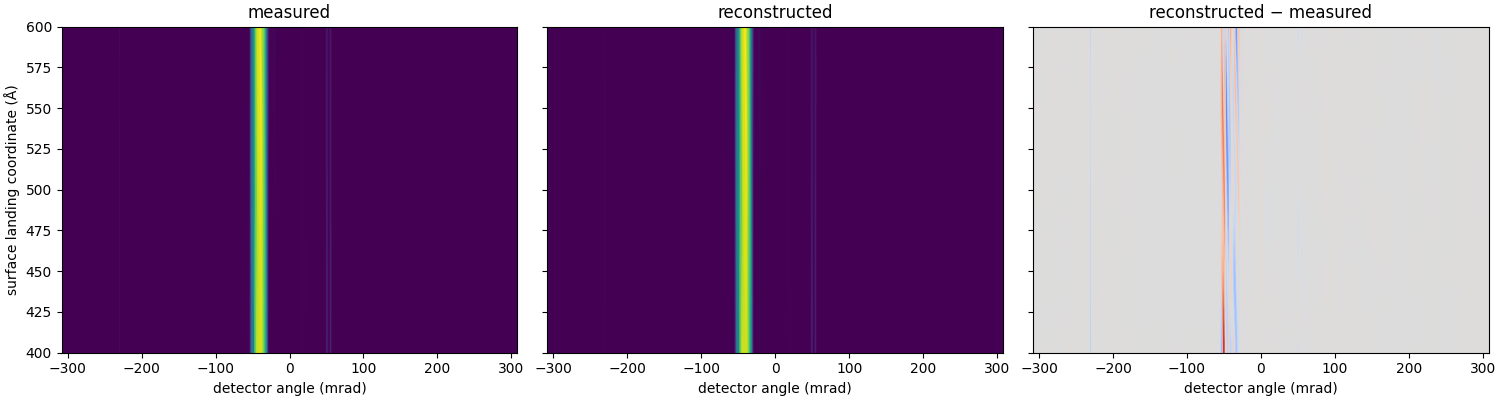

In [14]:
measured, predicted = np.asarray(defect_data), np.asarray(defect_result.predicted_intensities)
extent = [float(detector_angles_mrad[0]), float(detector_angles_mrad[-1]), 400.0, 600.0]
images = [measured, predicted, predicted - measured]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True, sharey=True)
for axis, image, title, cmap in zip(
        axes, images, ["measured", "reconstructed", "reconstructed − measured"],
        ["viridis", "viridis", "coolwarm"]):
    limit = np.max(np.abs(image)) if cmap == "coolwarm" else np.max(measured)
    axis.imshow(image, origin="lower", aspect="auto", extent=extent, cmap=cmap,
                vmin=-limit if cmap == "coolwarm" else 0.0, vmax=limit)
    axis.set(title=title, xlabel="detector angle (mrad)")
axes[0].set_ylabel("surface landing coordinate (Å)")


## Interpretation and limitations

Under the conditions considered here, the reconstruction asks a conditional question: given diamond Si, the approximate lattice scale, a fixed probe, known scan coordinates, a fixed exterior, and one latent layer for added atoms, which sparse edits and projected host displacements are supported by the diffraction data? The temporary pixel field can reveal a direction missing from the current physical state, but it cannot improve the final residual unless that direction is represented by a host displacement, vacancy, or added Si atom.

The present gates remain noiseless and use the same Lobato scattering parameterization on both sides of the comparison, although the forward and inverse potentials are rasterized independently. Unknown probe aberrations, scan errors, partial coherence, detector calibration, chemical identity, continuous depth, and experimental model mismatch are not reconstructed. The unopened audit scans test the selected state within this synthetic model; they do not establish uniqueness or experimental validity.
